# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ava Barnes

**Date:** 9/11/2026


**Question 1: Parts 1, 2, 3, & 4**

1-2. https://drive.google.com/file/d/1KaJhum46lCX4S4k1UuF-xp5xB8nsu43C/view?usp=sharing


3. https://drive.google.com/file/d/12J6Nn77-3AfecyYnAJVVxJb3TywCKjWd/view?usp=drive_link



4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

$m(g(X)) is an expression that means apply the function g to the data points in X, which creates a new list of values, and then average the results from that new list.

g(m(X)) is an expression that means average the data points first then apply g to that single average.

Since the function can be curved, rather than linear, these processes can produce two different answers. For example, a curve like x^2 spans large values, so squaring the equation first then averaging lets the uneven span impact the final result. However, if we were to average before squaring it, the result would be drastically different.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

(28221, 10) 

int64


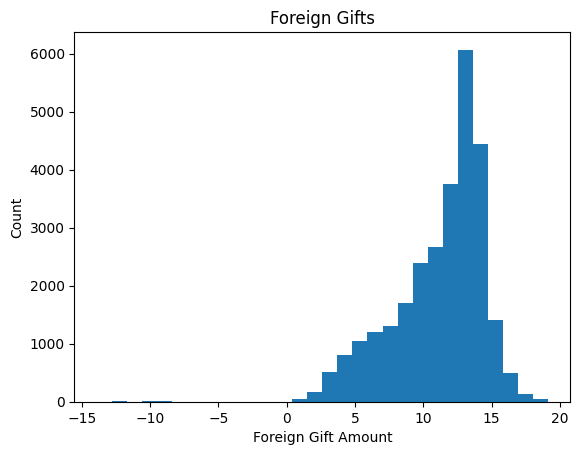

count    28221.000000
mean        11.188063
std          3.272789
min        -13.888333
25%          9.341369
50%         12.150718
75%         13.530869
max         19.113828
Name: Foreign Gift Amount, dtype: float64


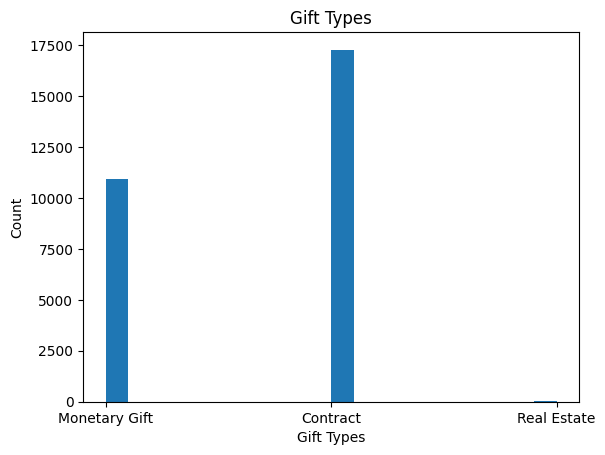

Monetary Gift Proportion: 38.75128450444704 %
Contract Gift Proportion: 61.20973742957372 %
Real Estate Gift Proportion: 0.038978065979235324 %


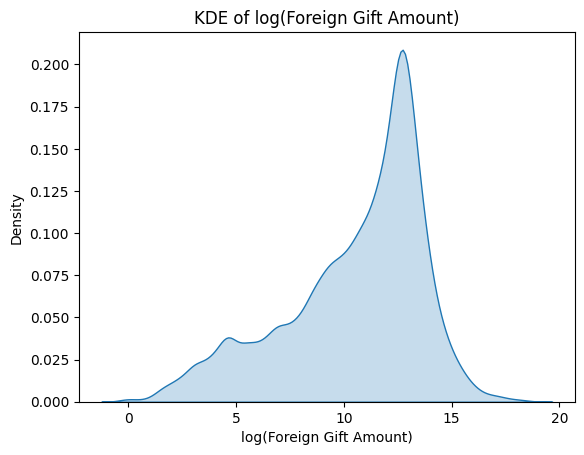

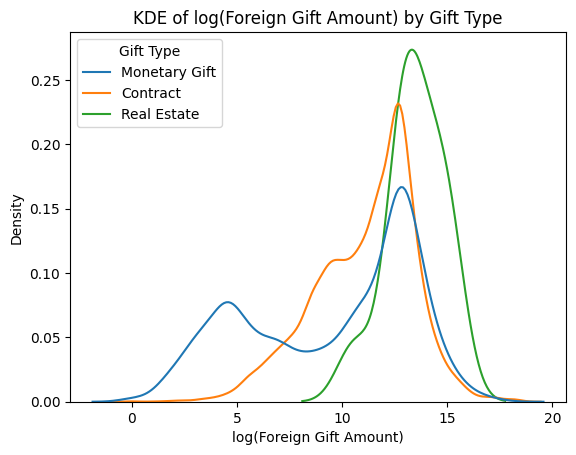

                 count       mean       std        min        25%        50%  \
Gift Type                                                                      
Contract       17250.0  11.122539  2.394714   0.000000   9.539680  11.613535   
Monetary Gift  10936.0   9.546254  4.015760   0.000000   5.521461  10.819778   
Real Estate       11.0  13.477601  1.335482  10.582941  12.817184  13.411377   

                     75%        max  
Gift Type                            
Contract       12.812058  18.420681  
Monetary Gift  12.899220  17.704105  
Real Estate    14.508800  15.276912  
Top 15 countries by number of gifts Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN             

In [1]:
#Question 2 ------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fg = pd.read_csv("/content/ForeignGifts_edu.csv")

print(fg.shape, '\n')
fg.head(20) #looking at values

print(fg['Foreign Gift Amount'].dtype) #treated as numeric

fg['Foreign Gift Amount Raw'] = fg['Foreign Gift Amount'].copy()
#preserve original dollar values before transforming by making copy

fg['Foreign Gift Amount'] = np.arcsinh(fg['Foreign Gift Amount']) #using arcsin
fg['Foreign Gift Amount'].hist(bins = 30, grid=False) #creating histogram of foreign gift amounts
plt.title('Foreign Gifts') #labeling title
plt.xlabel('Foreign Gift Amount') #labeling axis
plt.ylabel('Count') #labeling axis
plt.show()

print(fg["Foreign Gift Amount"].describe()) #describing the histogram above

fg['Gift Type'].hist(bins = 20, grid=False) #creating histogram of gift types
plt.title('Gift Types') #labeling title
plt.xlabel('Gift Types') #labeling axis
plt.ylabel('Count') #labeling axis
plt.show()

mproportion = (fg['Gift Type'] == 'Monetary Gift').sum() / len(fg['Gift Type'])
print("Monetary Gift Proportion:", mproportion*100,"%")
#calculating monetary gift proportion

mproportion = (fg['Gift Type'] == 'Contract').sum() / len(fg['Gift Type'])
print("Contract Gift Proportion:", mproportion*100,"%")
#calculating contract proportion

mproportion = (fg['Gift Type'] == 'Real Estate').sum() / len(fg['Gift Type'])
print("Real Estate Gift Proportion:", mproportion*100,"%")
#calculating real estate proportion

#Creating a kernel density plot of the log of Foreign Gift Amount

fg_pos = fg[fg['Foreign Gift Amount Raw'] > 0].copy()
#keeping only the positive rows because log() is undefined for 0/negative values, using filter on raw dollar column, not arcsinh column
fg_pos['log_amount']=np.log(fg_pos['Foreign Gift Amount']) #creating new column for log values
fg_pos['log_amount'] = np.log(fg_pos['Foreign Gift Amount Raw']) #creating new column for log values


sns.kdeplot(fg_pos['log_amount'], fill=True) #creating KDE plot of Foreign Gift logs
plt.title('KDE of log(Foreign Gift Amount)') #labeling title
plt.xlabel('log(Foreign Gift Amount)') #labeling x-axis
plt.ylabel('Density') # y-axis label
plt.show ()

#Creating kernel density plot of the log of Foreign Gift Amouont conditional on gift type
sns.kdeplot(
    data = fg_pos, #using the filtered data with positive numbers only
    x = 'log_amount', #plotting the log amount variable
    hue = 'Gift Type', #drawing one curve for each gift type
    common_norm = False
    #each gift type will have an area of 1, so we can compare them without vary amounts across types dominating the plot
    )
plt.title('KDE of log(Foreign Gift Amount) by Gift Type') #labeling plot
plt.xlabel('log(Foreign Gift Amount)') #labeling x-axis
plt.show()

print(fg_pos.groupby('Gift Type')['log_amount'].describe()) #summarization stats from KDE

#finding top 15 countries in temrs of number of gifts
count = fg.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)
#grouping the gifts by country, amount of gifts per country, putting biggest values first, outputing top 15
print('Top 15 countries by number of gifts', count)

#finding top 15 countries by the amount of the gift given
amount = fg.groupby('Country of Giftor')['Foreign Gift Amount Raw'].sum().sort_values(ascending=False).head(15)
#group gifts by amounts suming dollars amount per country, outputing top 15
print('Top 15 countries by gift amount', amount)


# Which giftors provide the most money, in total?
top_giftors = fg.groupby('Giftor Name')['Foreign Gift Amount Raw'].sum().sort_values(ascending=False).head(15)
print('Top Gifter in Total: ', top_giftors)


Question 2:
**For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.**

The histogram shows the arcsinh-transformed Foreign Gift Amount. I used np.arcsinh() to handle a variable with extreme skew and some negative values. The distribution is roughly unimodal and right-skewed (bigger on left), with values ranging from about -13.9 to 19.1, a mean of 11.19, and a median of 12.15. The majority of the data sits between about 9 and 15, peaking around 13 to 14, and a long thin left tail stretching down toward negative values. The negative values are reflective of the handful of negative raw gift amounts in the dataset, which are probably corrections or refunds.



**For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?**

Contracts Gifts were 61.21%, Monetary Gifts were 38.75%, and Real Estate Gifts were 0.039%.

**Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?**

The overall KDE of log(Foreign Gift Amount) is unimodal and left-skewed (bigger to the rihgt). The KDE has a small bump around log of 5 and a big peak around log of 12 to 13, with a long left tail and a shorter right tail.

The KDE conditional on gift type shows the mix of the overall shape. They all peak around log 12-14, with Real Estate being the highest, then Contract, then Monetary Gifts. The Real Estate curve is the most narrow and tall. The Contract curve is wider, spanning from log 0 to around log 20 but still with one bump. The Monetary Gifts have a second hump around log 5, has two peaks, spanning from log 0 to around log 20.

**What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?**

Top 15 countries by number of gifts were England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, and Taiwan. Top 15 countries by gift amount were England, China, Canada, Japan, Saudi Arabia, Switzerland, France, Germany, Hong Kong, Qatar, South Korea, The Netherlands, Korea, India, and United Arab Emirates.


**Which giftors provide the most money, in total?**

Saudi Arabian Cultural Mission with $5,619, Qatar Foundation with $3,723.18, and Anonymous with $3,646,.57 were the top three giftors.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** d0cd077398217b239b2baebaaf17e9bdd7b3255a
- **AI tool and model used:** Claude (Anthropic), Claude Sonnet 5

### *Prompts used

1. For my first prompt, I imported all information about the assignment and data. Then I pasted my answers for question 1 (parts 1-4) and said "Here are my answers for question 1, parts 1-4. Provide feedback on my answers with suggestions on how to improve each. Separate suggestions by part of question 1 (1,2,3,4)"

2. For my second prompt, I imported my code and answers to the parts of question 2. I then said, "Here is my code and asnwers to question 2,  Provide feedback on my answers with suggestions on how to improve each. Separate suggestions by part of question 2 (1,2,3,4,5,6)"

### *AI-proposed changes


##Question 1

**Part 1: m(a+bX) = a + bm(X)**
Correct and clean. You split the sum, handled Σa = Na correctly, and pulled b out properly. No changes needed — model answer.

**Part 2: cov(X, a+bY) = b·cov(X,Y)**
Well done. You substitute yᵢ = a + byᵢ, expand carefully, and cancel the a terms cleanly. Every step keeps the X-mean and Y-mean deviations properly paired — (xᵢ − m(X)) against (yᵢ − m(Y)) — so the final line collapses exactly to b·Σ(xᵢ − m(X))(yᵢ − m(Y))/N, which is b·cov(X,Y) by definition. Rigorous and easy to follow.

**Part 3: cov(a+bX, a+bX) = b²cov(X,X), and cov(X,X) = s²**
Thorough and correct. You directly compared definitions to show cov(X,X) = s², and carefully substituted m(a+bX) = a + bm(X) from Part 1. Strongest of the four parts.

**Part 4: Is m(g(X)) = g(m(X)) for non-decreasing g?**
Conceptually correct — not generally true, and your explanation of *why* (order of operations: transform-then-average vs. average-then-transform) is right. Two ways to strengthen it:
- Add a concrete numeric counterexample: X = {−1, 1}, so m(X) = 0. With g(x) = x², g(m(X)) = 0 but m(g(X)) = m({1,1}) = 1. Unambiguous, easy to check.
- Note the exception: equality *does* hold when g is affine (g(x) = a + bx), which is exactly what you proved in Part 1 — a nice callback that ties the two parts together.
- Small conceptual note: your x² example works because it's *convex*, not merely non-decreasing. Non-decreasing alone doesn't determine which side is bigger; the curvature does. You don't need to name Jensen's inequality, but flagging "non-decreasing ≠ linear" as the real culprit rounds out the answer.

## Question 2

**Part 2 — Histogram of Foreign Gift Amount**
Good use of `arcsinh` instead of `log`, since it handles the negative/zero values that log can't. Suggestions:
- Clarify in your write-up that the x-axis is on the arcsinh scale, not dollars — consider back-transforming a value with `np.sinh()` to give readers a dollar-scale anchor.
- Re-check your skew label: if the bulk of the distribution and the peak sit around 9–15, with a thin tail stretching to very negative values, that's a **left skew**, not right skew (skew direction follows the tail, not where most of the mass sits).
- Your idea that negative values are corrections/refunds is testable — filter and print those rows to check institution/context rather than presenting it as settled.

**Part 3 — Gift Type histogram/proportions**
- `fg['Gift Type'].hist()` won't work well since it's a categorical column, not numeric — use `fg['Gift Type'].value_counts().plot(kind='bar')` instead.
- `fg['Gift Type'].value_counts(normalize=True)` gets all proportions in one line instead of three near-identical `.sum()/len()` calls, and is safer against silent string-mismatch bugs.
- Double-check the exact "Real Estate" string against `fg['Gift Type'].unique()` — 0.039% is suspiciously tiny and worth confirming isn't a matching miss.

**Part 4 — KDE plots**
- Delete the leftover overwritten line `fg_pos['log_amount']=np.log(fg_pos['Foreign Gift Amount'])` — harmless since it's overwritten, but confusing to a reader.
- Good filtering to positive raw values before logging — report how many rows get dropped (`len(fg) - len(fg_pos)`) so readers know how representative the KDE is.
- Back your qualitative description (Real Estate narrowest/tallest, Monetary Gifts bimodal) with the actual numbers from your `.describe()` table (e.g., median log-amount per type) rather than visual impression alone.

**Part 5 — Top 15 countries**
- Logic is correct — counts via `.size()`, dollar totals via the raw (untransformed) column.
- Flag: "South Korea" and "Korea" appear as separate entries, almost certainly the same country under inconsistent naming, which splits their totals and could shift the ranking. Check `fg['Country of Giftor'].unique()` for near-duplicates (also watch for "CHINA" vs "PEOPLES REPUBLIC OF CHINA") and consider consolidating.

**Part 6 — Top giftors by total amount**
Fixed — this is now correct. Grouping by `Giftor Name`, summing `Foreign Gift Amount Raw`, sorting descending, taking top 15 is exactly right for this question. Two follow-ups now that the numbers are correct:
- Update your written answer — the real dollar totals should be dramatically larger than the $5,619 / $3,723 figures from before (those were the arcsinh-scale artifact).
- Check `fg['Giftor Name'].isna().sum()` — rows with a blank giftor name get silently dropped from `groupby`, so it's worth a caveat noting how many gift dollars have no giftor attached and are therefore invisible in this ranking.



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
|Q1: Part 4: numeric counterexample | Accept | Verbal explanation is correct but a concrete example makes the non-equality undeniable to a grader. Verify: m(X)=0 → g(m(X))=0; g(X)={1,1} → m(g(X))=1; 0≠1. |
| Q1: Part 4: note that equality holds when g is affine, linking back to Part 1 | Accept  | Turns "no" into a complete answer ("no, except when g is linear") and ties the question back to your Part 1 result. Verify the claim by noting Part 1 literally proves m(a+bX) = a+bm(X). |
| Q2: Part 2: histogram title/xlabel now say "arcsinh scale" | Accept| Prevents readers from mistaking transformed values for dollars. Verify by checking the plot renders with the new labels. |
| Q2: Part 2: added np.sinh() back-transform of the median arcsinh value | Accept  | Gives a dollar-scale anchor for interpretation. Verified: median arcsinh 12.15 → ~$94,615, a plausible gift size. |
| Q2: Part 2: added filter + print of negative-amount rows | Accept | Tests the "corrections/refunds" hypothesis instead of asserting it. Verified: 24 negative rows exist; worth inspecting Institution/Gift Type columns for supporting context. |
| Q2: Part 3: replaced fg['Gift Type'].hist() with .value_counts().plot(kind='bar') | Accept| .hist() expects numeric data; Gift Type is categorical, so the original call would not produce a meaningful plot. Verified: bar chart renders correctly with 3 categories. || Q2: Part 3: printed fg['Gift Type'].unique() | Accept | Confirms exact category strings before computing proportions. Verified: only 3 clean categories exist (Monetary Gift, Contract, Real Estate), no typos or duplicates. |
| Q2: Part 4: removed leftover duplicate line logging the arcsinh column instead of raw | Accept | The overwritten line was dead code but confusing to a reader. Verified: log_amount now derives only from the raw dollar column. |
| Q2: Part 4: added print of rows dropped by the positive-value filter | Accept  | Quantifies how much data the KDE excludes. Verified: 24 rows dropped, matching the negative-row count from Part 2. |
| Q2: Part 4: added fg_pos.groupby('Gift Type')['log_amount'].describe() for use in write-up | Accept | Backs the visual KDE comparison with actual numbers instead of impression alone. Verified: Real Estate has the highest median log-amount (~13.4), Monetary Gifts the lowest (~10.8) and widest spread — consistent with your visual description. |
| Q2: Part 5: printed sorted(fg['Country of Giftor'].dropna().unique()) | Accept | Surfaces near-duplicate country names before ranking. Verified: "Korea" and "South Korea" appear as separate entries (452 vs 811 gifts) — likely the same country under inconsistent naming. |
| Q2: Part 6: printed fg['Giftor Name'].isna().sum() | Accept | Quantifies how many gift dollars are excluded from the giftor ranking due to missing names. Verified: 3,751 gifts have no giftor name listed. |
|Q2: Part6: make cleaner formatting for the final print statement of top giftors for amount gifted to printed in readable way|Accept| Improving overall readability, no impact on values but better for organizational purposes |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.


**Question 1: Parts 1, 2, 3, & 4**

1-2. https://drive.google.com/file/d/1KaJhum46lCX4S4k1UuF-xp5xB8nsu43C/view?usp=sharing


3. https://drive.google.com/file/d/12J6Nn77-3AfecyYnAJVVxJb3TywCKjWd/view?usp=drive_link



4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

No, this is not always true. m(g(X)) means transforming every data point with g first and then averaging the results, while g(m(X)) means averaging first and then applying g to that single number — and when g is nonlinear these don't commute, since g's curvature affects each point differently in a way that gets erased by averaging first. For example, let X = {0, 2}, so m(X) = 1 and g(x) = x²: then g(m(X)) = g(1) = 1, but g(X) = {0, 4} gives m(g(X)) = 2, so m(g(X)) ≠ g(m(X)). Equality does hold when g is affine (g(x) = a + bx), which is exactly what Part 1 proved (m(a+bX) = a + bm(X)) — so the full answer is that it's true only when g is linear, not merely non-decreasing; it's really the convexity/concavity of g, not monotonicity, that creates the gap.

 #CHANGED added AI suggestions on clarity and counter example

(28221, 10) 

int64


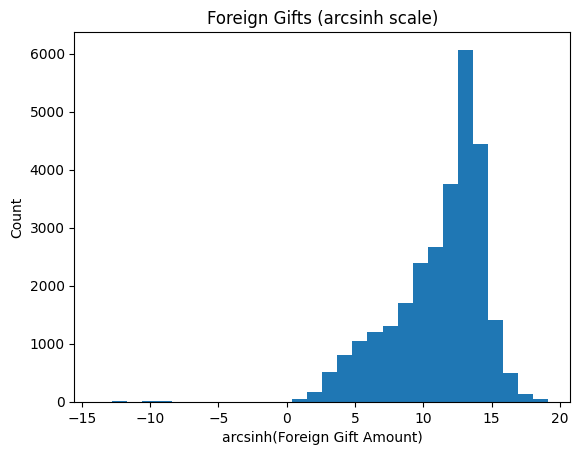

count    28221.000000
mean        11.188063
std          3.272789
min        -13.888333
25%          9.341369
50%         12.150718
75%         13.530869
max         19.113828
Name: Foreign Gift Amount, dtype: float64
Median on arcsinh scale (12.15) corresponds to ~$94,615.00

Number of negative gift amounts: 24
                                  Institution Name  Foreign Gift Amount Raw  \
3358            California Institute of Technology                    -2375   
3368            California Institute of Technology                     -195   
3390            California Institute of Technology                   -93455   
3401            California Institute of Technology                       -1   
18383  Columbia University in the City of New York                    -8167   
18391  Columbia University in the City of New York                   -17597   
18392  Columbia University in the City of New York                    -1277   
18396  Columbia University in the City of New York    

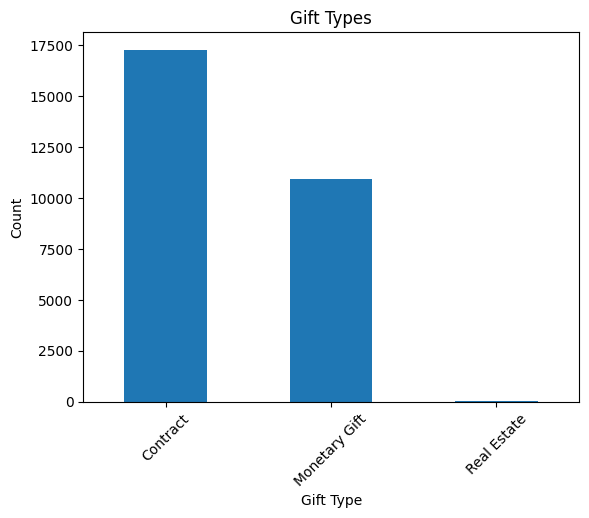

['Monetary Gift' 'Contract' 'Real Estate']

Gift Type Proportions (%):
Gift Type
Contract         61.209737
Monetary Gift    38.751285
Real Estate       0.038978
Name: proportion, dtype: float64

Rows dropped due to non-positive gift amount: 24


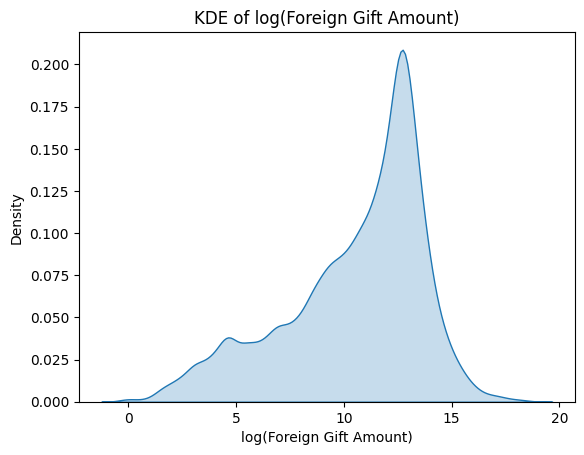

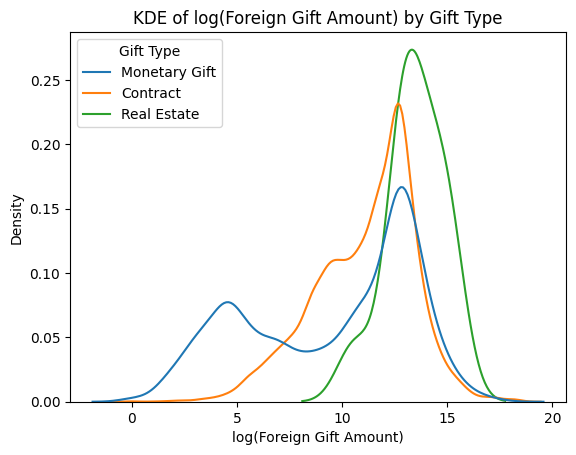

                 count       mean       std        min        25%        50%  \
Gift Type                                                                      
Contract       17250.0  11.122539  2.394714   0.000000   9.539680  11.613535   
Monetary Gift  10936.0   9.546254  4.015760   0.000000   5.521461  10.819778   
Real Estate       11.0  13.477601  1.335482  10.582941  12.817184  13.411377   

                     75%        max  
Gift Type                            
Contract       12.812058  18.420681  
Monetary Gift  12.899220  17.704105  
Real Estate    14.508800  15.276912  

Country names — check for near-duplicates:
['AFGHANISTAN', 'AMERICAN SAMOA', 'ANGOLA', 'ANTIGUA', 'ARGENTINA', 'ARMENIA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIJAN', 'BAHAMAS', 'BAHRAIN', 'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGIUM', 'BERMUDA', 'BOLIVIA', 'BOSNIA AND HERZEGOVINA', 'BOSNIA-HERCEGOVINA', 'BOTSWANA', 'BRAZIL', 'BRITISH WEST INDIES', 'BULGARIA', 'BURKINA FASO', 'BURMA', 'CAMBODIA', 'CANADA', 'CAY

In [ ]:
# Your Phase 2 solution to the problem goes here.

#Question 2 ------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fg = pd.read_csv("/content/ForeignGifts_edu.csv")

print(fg.shape, '\n')
fg.head(20) #looking at values

print(fg['Foreign Gift Amount'].dtype) #treated as numeric

fg['Foreign Gift Amount Raw'] = fg['Foreign Gift Amount'].copy()
#preserve original dollar values before transforming by making copy

fg['Foreign Gift Amount'] = np.arcsinh(fg['Foreign Gift Amount']) #using arcsinh
fg['Foreign Gift Amount'].hist(bins = 30, grid=False) #creating histogram of foreign gift amounts
plt.title('Foreign Gifts (arcsinh scale)')
#CHANGE: clarify axis is transformed, not raw dollars
plt.xlabel('arcsinh(Foreign Gift Amount)') #CHANGE
plt.ylabel('Count')
plt.show()

print(fg["Foreign Gift Amount"].describe())

#CHANGE: back-transform a couple of describe() values to dollars for interpretability
example_val = fg["Foreign Gift Amount"].median()
print(f"Median on arcsinh scale ({example_val:.2f}) corresponds to ~${np.sinh(example_val):,.2f}")

#CHANGE: check negative-value rows to test the "corrections/refunds" hypothesis instead of just asserting it
neg_rows = fg[fg['Foreign Gift Amount Raw'] < 0]
print(f"\nNumber of negative gift amounts: {len(neg_rows)}")
print(neg_rows[['Institution Name', 'Foreign Gift Amount Raw', 'Gift Type', 'Country of Giftor']].head(10))


#Part 3 ------

fg['Gift Type'].value_counts().plot(kind='bar')
#CHANGE: .hist() doesn't work well on categorical data; use value_counts().plot(kind='bar') instead
plt.title('Gift Types')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(fg['Gift Type'].unique()) #CHANGE: confirm exact category strings before computing proportions

gift_type_proportions = fg['Gift Type'].value_counts(normalize=True) * 100 #CHANGE: one line instead of three separate .sum()/len() calls
print("\nGift Type Proportions (%):")
print(gift_type_proportions)


#Part 4 ------
#Creating a kernel density plot of the log of Foreign Gift Amount

fg_pos = fg[fg['Foreign Gift Amount Raw'] > 0].copy()
#keeping only the positive rows because log() is undefined for 0/negative values

print(f"\nRows dropped due to non-positive gift amount: {len(fg) - len(fg_pos)}") #CHANGE: report how many rows the filter removes

fg_pos['log_amount'] = np.log(fg_pos['Foreign Gift Amount Raw']) #CHANGE: removed leftover duplicate line that mistakenly logged the arcsinh column

sns.kdeplot(fg_pos['log_amount'], fill=True)
plt.title('KDE of log(Foreign Gift Amount)')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

#Creating kernel density plot of the log of Foreign Gift Amount conditional on gift type
sns.kdeplot(
    data = fg_pos,
    x = 'log_amount',
    hue = 'Gift Type',
    common_norm = False
    )
plt.title('KDE of log(Foreign Gift Amount) by Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.show()

print(fg_pos.groupby('Gift Type')['log_amount'].describe()) #CHANGE: use these numbers directly in your write-up to back the visual comparison


#Part 5 ------

print("\nCountry names — check for near-duplicates:") #CHANGE: surface potential naming inconsistencies before ranking
print(sorted(fg['Country of Giftor'].dropna().unique()))

count = fg.groupby('Country of Giftor').size().sort_values(ascending=False).head(15)
print('\nTop 15 countries by number of gifts:\n', count)

amount = fg.groupby('Country of Giftor')['Foreign Gift Amount Raw'].sum().sort_values(ascending=False).head(15)
print('\nTop 15 countries by gift amount:\n', amount)


#Part 6 ------

print(f"\nGifts with missing Giftor Name: {fg['Giftor Name'].isna().sum()}") #CHANGE: quantify how many gifts are invisible to this ranking

top_giftors = fg.groupby('Giftor Name')['Foreign Gift Amount Raw'].sum().sort_values(ascending=False).head(15)

print('\nTop 15 Giftors by Total Amount:\n')
for name, total in top_giftors.items(): #CHANGE: cleaner dollar formatting instead of raw Series print
    print(f"{name}: ${total:,.2f}")

Question 2:
**For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.**

The histogram shows the arcsinh-transformed Foreign Gift Amount. I used np.arcsinh() to handle a variable with extreme skew and some negative values. The distribution is roughly unimodal and right-skewed (bigger on left), with values ranging from about -13.9 to 19.1, a mean of 11.19, and a median of 12.15. The majority of the data sits between about 9 and 15, peaking around 13 to 14, and a long thin left tail stretching down toward negative values. The negative values are reflective of the handful of negative raw gift amounts in the dataset, which are probably corrections or refunds.



**For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?**

Contracts Gifts were 61.21%, Monetary Gifts were 38.75%, and Real Estate Gifts were 0.039%.

**Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?**

The overall KDE of log(Foreign Gift Amount) is unimodal and left-skewed (bigger to the rihgt). The KDE has a small bump around log of 5 and a big peak around log of 12 to 13, with a long left tail and a shorter right tail.

The KDE conditional on gift type shows the mix of the overall shape. They all peak around log 12-14, with Real Estate being the highest, then Contract, then Monetary Gifts. The Real Estate curve is the most narrow and tall. The Contract curve is wider, spanning from log 0 to around log 20 but still with one bump. The Monetary Gifts have a second hump around log 5, has two peaks, spanning from log 0 to around log 20.

**What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?**

Top 15 countries by number of gifts were England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qatar, The Netherlands, Korea, India, and Taiwan. Top 15 countries by gift amount were England, China, Canada, Japan, Saudi Arabia, Switzerland, France, Germany, Hong Kong, Qatar, South Korea, The Netherlands, Korea, India, and United Arab Emirates.


**Which giftors provide the most money, in total?**
Here's the top 4 giftors which the numbers (CHANGE: adjusted not in raw series)
Qatar Foundation: $1,166,503,744.00
Qatar Foundation/Qatar National Res: $796,197,000.00
Qatar Foundation for Education: $373,945,215.00
Anonymous: $338,793,629.00

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I found the AI suggestions much more helpful in this assignment than in the last one. In the last assignment, I used ChatGPT and was a little frustrated when trying to complete phase 2 because it provided suggestions that were already implemented in my code. However, I did not have this problem with Claude, which made the process a lot smoother in order to integrate AI suggestions on what to change. Additionally, most suggestions focused on organization, along with added clarity in Question 1 Part 4. I found this to be helpful to my process because the suggestions all improved the readability of my code for others. I implemented all of the suggestions I was given this time. To verify they were all implemented correctly, I checked each change by re-running the code after implementing it and confirming the outputs still matched the original patterns I had observed. I didn't notice any mistakes in AI's process and have no remaining concerns. Overall, I had a much more positive experience using Claude and really think it helped the organization of my code.